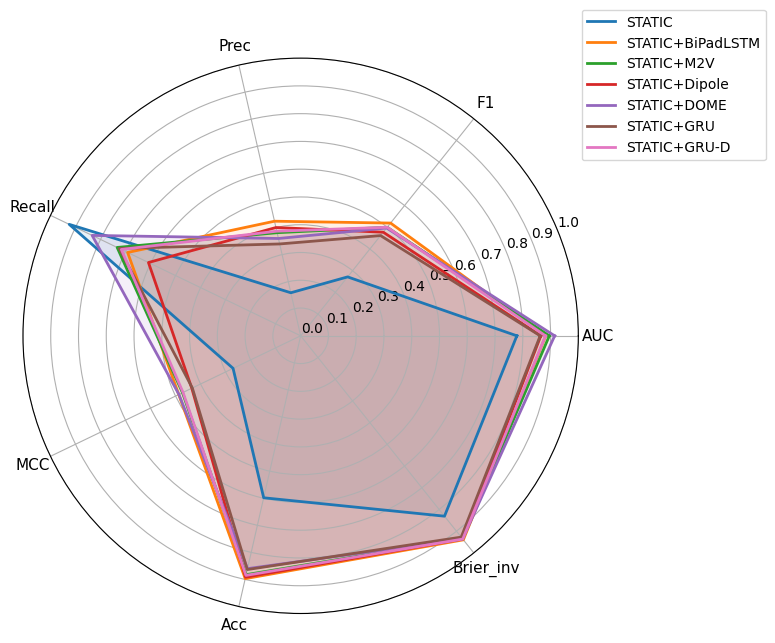

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Lettura CSV
df = pd.read_csv("results_INA_orig_final.csv")

df.columns = [
    "Model",
    "AUC","AUC_std",
    'F1', 'F1 std', 'Prec',
       'Prec std', 'Recall', 'Recall std', 'MCC', 'MCC std',
       'Acc', 'Acc std', 'CM', 'Brier'
]

# Calcolo Precision dalla confusion matrix
def precision_from_cm(cm_str):
    cm = eval(cm_str)
    tn, fp = cm[0]
    fn, tp = cm[1]
    return tp / (tp + fp)

#df["Prec"] = df["CM"].apply(precision_from_cm)

# Invertiamo il Brier score (più basso è meglio)
df["Brier_inv"] = 1 - df["Brier"]

metrics = [
    "AUC",
    "F1",
    "Prec",
    "Recall",
    "MCC",
    "Acc",
    "Brier_inv"
]

# Radar plot
N = len(metrics)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for _, row in df.iterrows():
    values = row[metrics].tolist()
    values += values[:1]

    ax.plot(angles, values, linewidth=2, label=row["Model"])
    ax.fill(angles, values, alpha=0.1)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(metrics, fontsize=11)

ax.set_ylim(0, 1)
ax.set_yticks(np.arange(0, 1.1, 0.1))
ax.set_yticklabels([f"{x:.1f}" for x in np.arange(0, 1.1, 0.1)])

ax.grid(True)
#plt.title("Model Comparison Radar Plot", pad=20)
plt.legend(loc="upper right", bbox_to_anchor=(1.35, 1.1))
plt.tight_layout()
plt.show()

In [38]:
fig.savefig("MIMIC_radar.png")